<a href="https://colab.research.google.com/github/Mujtaba-124/DATA-mining-repository/blob/main/YOLO_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Mon May 11 10:00:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# New Section

In [ ]:
!unzip label-studiodatazip.zip

Archive:  label-studiodatazip.zip
   creating: images/
   creating: labels/
  inflating: classes.txt             
  inflating: notes.json              
  inflating: images/01eba6ac-10.PNG  
  inflating: images/03a01245-18.PNG  
  inflating: images/05731a00-42.PNG  
  inflating: images/0c388da9-35.PNG  
  inflating: images/0c5dd6ac-34.PNG  
  inflating: images/0cffc50b-16.PNG  
  inflating: images/144828db-28.PNG  
  inflating: images/157f3c3d-14.PNG  
  inflating: images/1e17fb52-11.PNG  
  inflating: images/1e5c9697-19.PNG  
  inflating: images/2cc021dc-2.PNG   
  inflating: images/3659ae72-15.PNG  
  inflating: images/3d3365fc-3.PNG   
  inflating: images/40809ef7-50.PNG  
  inflating: images/42c8fd3c-29.PNG  
  inflating: images/4a854ca1-51.PNG  
  inflating: images/4c502c4c-39.PNG  
  inflating: images/5e715c06-33.PNG  
  inflating: images/5fb30450-52.PNG  
  inflating: images/629f8265-27.PNG  
  inflating: images/6a1e2b16-40.PNG  
  inflating: images/70de354f-44.PNG  
  inflating:

In [ ]:
!ls

classes.txt  images  labels  label-studiodatazip.zip  notes.json  sample_data


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!cat classes.txt

Buildings
Forest
House
Industrial
Lake
Pasture
Residential
Road
Tree
crops
vehicles


In [ ]:
%%writefile data.yaml
path: /content
train: images
val: images

names:
  0: Buildings
  1: Forest
  2: House
  3: Industrial
  4: Lake
  5: Pasture
  6: Residential
  7: Road
  8: Tree
  9: crops
  10: vehicles4

Writing data.yaml


In [ ]:
!cat data.yaml

path: /content
train: images
val: images

names:
  0: Buildings
  1: Forest
  2: House
  3: Industrial
  4: Lake
  5: Pasture
  6: Residential
  7: Road
  8: Tree
  9: crops
  10: vehicles4


In [ ]:
!ls images | wc -l
!ls labels | wc -l

51
51


In [ ]:
!nvidia-smi

Mon May 11 12:51:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os

os.makedirs("/content/data/train/images", exist_ok=True)
os.makedirs("/content/data/train/labels", exist_ok=True)
os.makedirs("/content/data/val/images", exist_ok=True)
os.makedirs("/content/data/val/labels", exist_ok=True)

In [ ]:
import os
import random
import shutil

image_dir = "/content/images"
label_dir = "/content/labels"

train_img_dir = "/content/data/train/images"
train_lbl_dir = "/content/data/train/labels"
val_img_dir = "/content/data/val/images"
val_lbl_dir = "/content/data/val/labels"

os.makedirs(train_img_dir, exist_ok=True)
os.makedirs(train_lbl_dir, exist_ok=True)
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_lbl_dir, exist_ok=True)

images = os.listdir(image_dir)
random.shuffle(images)

split_ratio = 0.8
split_index = int(len(images) * split_ratio)

train_images = images[:split_index]
val_images = images[split_index:]

def copy_files(image_list, img_dest, lbl_dest):
    for img in image_list:
        img_path = os.path.join(image_dir, img)

        # create label name safely
        label_name = os.path.splitext(img)[0] + ".txt"
        label_path = os.path.join(label_dir, label_name)

        # copy image
        shutil.copy(img_path, os.path.join(img_dest, img))

        # copy label only if exists
        if os.path.exists(label_path):
            shutil.copy(label_path,
                        os.path.join(lbl_dest, label_name))
        else:
            print(f"⚠️ Missing label skipped: {img}")

copy_files(train_images, train_img_dir, train_lbl_dir)
copy_files(val_images, val_img_dir, val_lbl_dir)

print("Dataset split completed safely!")

Dataset split completed safely!


In [ ]:
!ls data/train/images | wc -l
!ls data/train/labels | wc -l

40
40


In [ ]:
!ls labels | head

01eba6ac-10.txt
03a01245-18.txt
05731a00-42.txt
0c388da9-35.txt
0c5dd6ac-34.txt
0cffc50b-16.txt
144828db-28.txt
157f3c3d-14.txt
1e17fb52-11.txt
1e5c9697-19.txt


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e49b9fd97c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

In [ ]:
results = model.predict(
    source="/content/images",
    conf=0.25,
    save=True
)


image 1/51 /content/images/01eba6ac-10.PNG: 512x640 1 Forest, 44.1ms
image 2/51 /content/images/03a01245-18.PNG: 416x640 (no detections), 40.7ms
image 3/51 /content/images/05731a00-42.PNG: 416x640 3 Buildingss, 7.2ms
image 4/51 /content/images/0c388da9-35.PNG: 448x640 1 House, 66.5ms
image 5/51 /content/images/0c5dd6ac-34.PNG: 480x640 2 Forests, 61.7ms
image 6/51 /content/images/0cffc50b-16.PNG: 384x640 11 Residentials, 60.3ms
image 7/51 /content/images/144828db-28.PNG: 448x640 (no detections), 8.5ms
image 8/51 /content/images/157f3c3d-14.PNG: 320x640 (no detections), 62.9ms
image 9/51 /content/images/1e17fb52-11.PNG: 384x640 (no detections), 8.3ms
image 10/51 /content/images/1e5c9697-19.PNG: 416x640 (no detections), 8.5ms
image 11/51 /content/images/2cc021dc-2.PNG: 256x640 7 Buildingss, 3 Residentials, 57.1ms
image 12/51 /content/images/3659ae72-15.PNG: 384x640 10 Buildingss, 2 Residentials, 8.9ms
image 13/51 /content/images/3d3365fc-3.PNG: 640x544 26 Residentials, 57.6ms
image 14/51

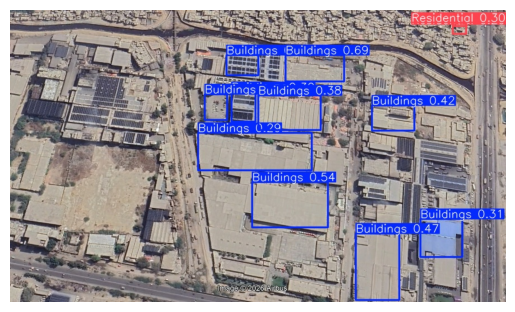

In [ ]:
import cv2
import matplotlib.pyplot as plt

path = "runs/detect/predict/3659ae72-15.jpg"  # change this

img = cv2.imread(path)

if img is None:
    print("Image not found. Check filename in runs/detect/predict/")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
from IPython.display import Image, display

display(Image("runs/detect/predict/img1.jpg"))